In [256]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import recall_score, ConfusionMatrixDisplay, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

In [257]:
df1 = pd.read_csv('dados/dados_modelo1.csv')
df2 = pd.read_csv('dados/dados_modelo2.csv')
df3 = pd.read_csv('dados/dados_modelo3.csv')

### 1- Dividindo as features e a resposta

In [258]:
X1 = df1.drop('Reprovou', axis = 1)
y1 = df1['Reprovou']
# X1.drop('TempoQ3', axis = 1, inplace = True)

X2 = df2.drop('Reprovou', axis = 1)
y2 = df2['Reprovou']
# X2.drop('TempoQ3', axis = 1, inplace = True)

X3 = df3.drop('Reprovou', axis = 1)
y3 = df3['Reprovou']
# X3.drop('TempoQ3', axis = 1, inplace = True)

### 2- Preenchendo valores nulos no tempo do quizz 3

In [259]:
X1['TempoQ3'] = X1['TempoQ3'].fillna(0)
X2['TempoQ3'] = X2['TempoQ3'].fillna(0)
X3['TempoQ3'] = X3['TempoQ3'].fillna(0)



### 3- Splitando os tres data frames e treinando o modelo

Melhores parâmetros: NearestCentroid(metric='manhattan')
Recall da classe 0 no teste: 0.6363636363636364


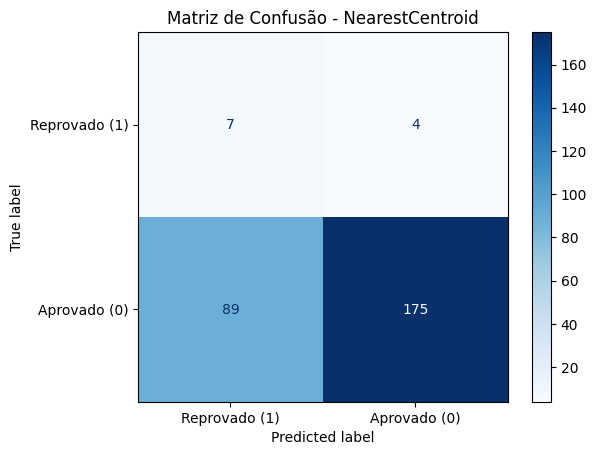

In [260]:

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1,test_size=0.2, random_state=42)

sm = SMOTE(random_state=42)
X1_train, y1_train = sm.fit_resample(X1_train, y1_train)

# Definição do classificador
nc = NearestCentroid()

# Grid de parâmetros
param_grid = {
    "metric": ["euclidean", "manhattan"],  
    "shrink_threshold": [None, 0.1, 0.5, 1.0]
}


grid1 = GridSearchCV(nc, param_grid, cv=5, scoring='recall')
grid1.fit(X1_train, y1_train)

melhor_modelo1 = grid1.best_estimator_

print("Melhores parâmetros:", melhor_modelo1)

y1_pred = grid1.predict(X1_test)
recall_classe_0 = recall_score(y1_test, y1_pred)
print("Recall da classe 0 no teste:", recall_classe_0)

confusion_matrix(y1_test, y1_pred, labels=[1,0])

disp = ConfusionMatrixDisplay.from_predictions(
    y1_test,
    y1_pred,
    display_labels=["Reprovado (1)", "Aprovado (0)"],  
    cmap="Blues",
    values_format="d",
    labels = [1,0]
)

plt.title("Matriz de Confusão - NearestCentroid")
plt.show()


Melhores parâmetros: NearestCentroid(metric='manhattan', shrink_threshold=1.0)
Recall da classe 0 no teste: 0.7272727272727273


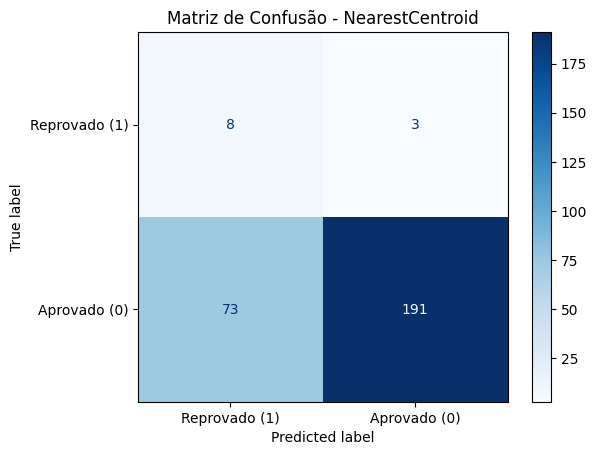

In [261]:

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2,test_size=0.2, random_state=42)

sm = SMOTE(random_state=42)
X2_train, y2_train = sm.fit_resample(X2_train, y2_train)

# Definição do classificador
nc = NearestCentroid()

# Grid de parâmetros
param_grid = {
    "metric": ["euclidean", "manhattan"],  
    "shrink_threshold": [None, 0.1, 0.5, 1.0]
}


grid2 = GridSearchCV(nc, param_grid, cv=5, scoring='recall')
grid2.fit(X2_train, y2_train)

melhor_modelo2 = grid2.best_estimator_

print("Melhores parâmetros:", melhor_modelo2)

y2_pred = grid2.predict(X2_test)
recall_classe_0 = recall_score(y2_test, y2_pred)
print("Recall da classe 0 no teste:", recall_classe_0)

confusion_matrix(y2_test, y2_pred, labels=[1,0])

disp = ConfusionMatrixDisplay.from_predictions(
    y2_test,
    y2_pred,
    display_labels=["Reprovado (1)", "Aprovado (0)"],  
    cmap="Blues",
    values_format="d",
    labels = [1,0]
)

plt.title("Matriz de Confusão - NearestCentroid")
plt.show()


Melhores parâmetros: NearestCentroid(metric='manhattan', shrink_threshold=0.5)
Recall da classe 0 no teste: 0.8181818181818182


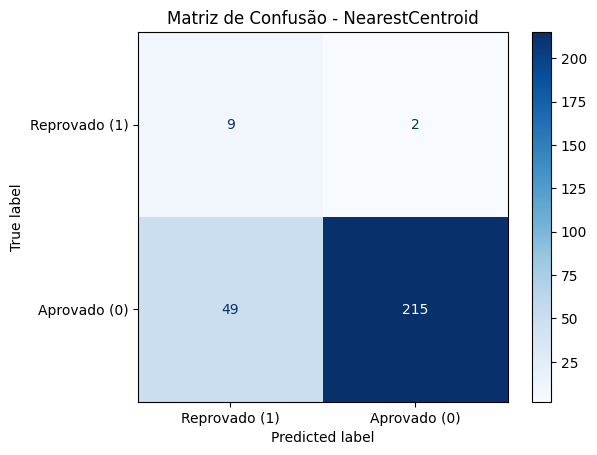

In [262]:

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3,test_size=0.2, random_state=42)

sm = SMOTE(random_state=42)
X3_train, y3_train = sm.fit_resample(X3_train, y3_train)

# Definição do classificador
nc = NearestCentroid()

# Grid de parâmetros
param_grid = {
    "metric": ["euclidean", "manhattan"],  
    "shrink_threshold": [None, 0.1, 0.5, 1.0]
}

grid3 = GridSearchCV(nc, param_grid, cv=5, scoring='recall')
grid3.fit(X3_train, y3_train)

melhor_modelo3 = grid3.best_estimator_

print("Melhores parâmetros:", melhor_modelo3)

y3_pred = grid3.predict(X3_test)
recall_classe_0 = recall_score(y3_test, y3_pred)
print("Recall da classe 0 no teste:", recall_classe_0)

confusion_matrix(y3_test, y3_pred, labels=[1,0])

disp = ConfusionMatrixDisplay.from_predictions(
    y3_test,
    y3_pred,
    display_labels=["Reprovado (1)", "Aprovado (0)"],  
    cmap="Blues",
    values_format="d",
    labels = [1,0]
)

plt.title("Matriz de Confusão - NearestCentroid")
plt.show()
